In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)

# Load saved splits
X_train, X_test, y_train, y_test = joblib.load('processed_data.pkl')

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("Data loaded ✅")


Train: (5634, 40) | Test: (1409, 40)
Data loaded ✅


In [2]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION")
print(f"  Accuracy : {accuracy_score(y_test, lr_preds)*100:.1f}%")
print(f"  AUC-ROC  : {roc_auc_score(y_test, lr_probs):.3f}")

LOGISTIC REGRESSION
  Accuracy : 80.6%
  AUC-ROC  : 0.842


In [3]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

print("RANDOM FOREST")
print(f"  Accuracy : {accuracy_score(y_test, rf_preds)*100:.1f}%")
print(f"  AUC-ROC  : {roc_auc_score(y_test, rf_probs):.3f}")

RANDOM FOREST
  Accuracy : 78.3%
  AUC-ROC  : 0.818


In [4]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

print("XGBOOST")
print(f"  Accuracy : {accuracy_score(y_test, xgb_preds)*100:.1f}%")
print(f"  AUC-ROC  : {roc_auc_score(y_test, xgb_probs):.3f}")

C:\Users\lenovo\OneDrive\Desktop\churn-consulting-project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:24:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBOOST
  Accuracy : 80.3%
  AUC-ROC  : 0.845


In [5]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, lr_probs),
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, xgb_probs)
    ]
})

results['Accuracy'] = (results['Accuracy'] * 100).round(1)
results['AUC-ROC'] = results['AUC-ROC'].round(3)
results = results.sort_values('AUC-ROC', ascending=False)

print(results.to_string(index=False))

              Model  Accuracy  AUC-ROC
            XGBoost      80.3    0.845
Logistic Regression      80.6    0.842
      Random Forest      78.3    0.818


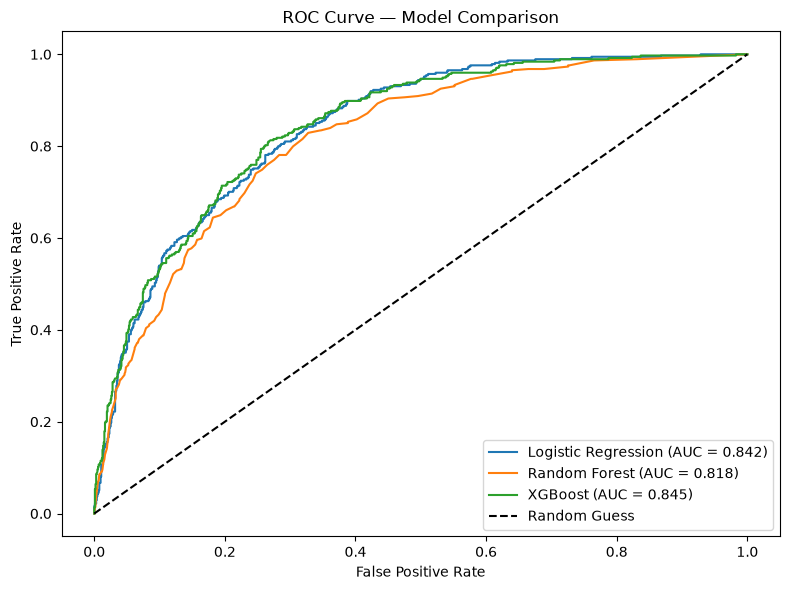

In [6]:
plt.figure(figsize=(8, 6))

for name, probs in [('Logistic Regression', lr_probs),
                     ('Random Forest', rf_probs),
                     ('XGBoost', xgb_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

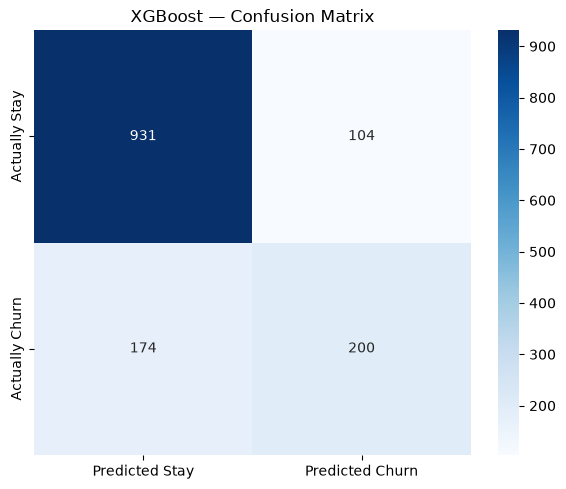

Correctly identified churners : 200
Missed churners (False Neg)   : 174  ← customers we lost silently
Wrong alarms (False Pos)      : 104  ← retention effort wasted


In [7]:
cm = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stay', 'Predicted Churn'],
            yticklabels=['Actually Stay', 'Actually Churn'])
plt.title('XGBoost — Confusion Matrix')
plt.tight_layout()
plt.show()

# Business translation
tn, fp, fn, tp = cm.ravel()
print(f"Correctly identified churners : {tp}")
print(f"Missed churners (False Neg)   : {fn}  ← customers we lost silently")
print(f"Wrong alarms (False Pos)      : {fp}  ← retention effort wasted")

In [8]:
print("XGBoost — Full Classification Report")
print(classification_report(y_test, xgb_preds, target_names=['Stay', 'Churn']))

XGBoost — Full Classification Report
              precision    recall  f1-score   support

        Stay       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [9]:
joblib.dump(xgb, 'xgb_churn_model.pkl')
print("XGBoost model saved ✅")
print("\n→ Ready for Phase 4: SHAP Analysis 🚀")

XGBoost model saved ✅

→ Ready for Phase 4: SHAP Analysis 🚀
